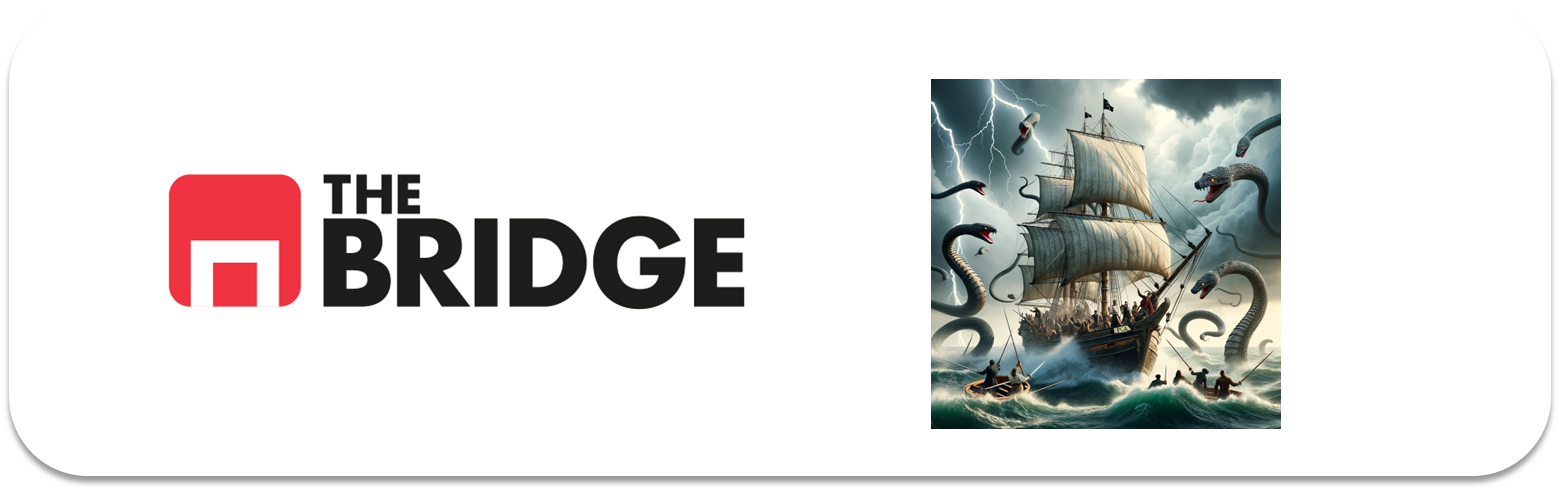

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [70]:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

#import warnings library
import warnings
# ignore all warnings
warnings.filterwarnings('ignore')

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [71]:
df = pd.read_csv("./data/credit_npo.csv")
df["SeriousDlqin2yrs"].value_counts()
features_all = df.columns.to_list()

In [72]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,12537.000000,12537.000000,12537.000000,12537.000000,12537.000000,11816.000000,12537.000000,12537.000000,12537.000000,12537.000000,12360.000000
mean,0.068916,0.330359,52.079445,0.409588,1.902253,6864.815420,8.482332,0.259312,0.999202,0.228364,0.822087
std,0.253321,0.368148,15.077498,4.055787,9.122216,11855.905437,5.165422,4.035658,1.134325,4.018873,1.136802
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030651,41.000000,0.000000,0.142268,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.163490,51.000000,0.000000,0.302025,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.582219,62.000000,0.000000,0.506725,8300.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,6.000000,101.000000,98.000000,99.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


In [73]:
df = df.rename(columns={'RevolvingUtilizationOfUnsecuredLines': 'UnsecuredLines'})

In [74]:
df = df.rename(columns={'NumberOfTime30-59DaysPastDueNotWorse': 'Time30-59Days'})
df = df.rename(columns={'NumberOfOpenCreditLinesAndLoans': 'open_Credit_Loan'})
df = df.rename(columns={'NumberOfTime60-89DaysPastDueNotWorse': 'Time60-89Days'})
df = df.rename(columns={'NumberOfTimes90DaysLate': 'Time90Dayslate'})

In [75]:
df =  df[df["Time60-89Days"] != 98]

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12516 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SeriousDlqin2yrs              12516 non-null  int64  
 1   UnsecuredLines                12516 non-null  float64
 2   age                           12516 non-null  int64  
 3   Time30-59Days                 12516 non-null  int64  
 4   DebtRatio                     12516 non-null  float64
 5   MonthlyIncome                 11806 non-null  float64
 6   open_Credit_Loan              12516 non-null  int64  
 7   Time90Dayslate                12516 non-null  int64  
 8   NumberRealEstateLoansOrLines  12516 non-null  int64  
 9   Time60-89Days                 12516 non-null  int64  
 10  NumberOfDependents            12341 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 1.1 MB


In [77]:
df["NumberOfDependents"].value_counts(normalize= True)*100

NumberOfDependents
0.0     56.048943
1.0     19.317721
2.0     14.707074
3.0      7.146909
4.0      2.050077
5.0      0.502390
6.0      0.194474
8.0      0.016206
10.0     0.008103
7.0      0.008103
Name: proportion, dtype: float64

In [78]:

bins_30_59days = [-1, 0, 1, 2, float("inf")]
labels_30_59days = [0, 1, 2, 3]
df["Time30-59Days"] = pd.cut(df["Time30-59Days"], bins=bins_30_59days, labels=labels_30_59days)

bins_dep = [-1, 0, 1, 2, 3, float("inf")]
labels_dep = [0, 1, 2, 3, 4]
df["NumberOfDependents"] = pd.cut(df["NumberOfDependents"], bins=bins_dep, labels=labels_dep)

bins_dep = [-1, 0, 1, float("inf")]
labels_dep = [0, 1, 2]
df["Time60-89Days"] = pd.cut(df["Time60-89Days"], bins=bins_dep, labels=labels_dep)

bins_dep = [-1, 0, 1, float("inf")]
labels_dep = [0, 1,2]
df["Time90Dayslate"] = pd.cut(df["Time90Dayslate"], bins=bins_dep, labels=labels_dep)

In [81]:
transformed_cat = ["Time30-59Days", "NumberOfDependents", "Time60-89Days", "Time90Dayslate"]
for col in transformed_cat:
    pd.get_dummies(df, columns=[col], drop_first=True)

In [80]:
df

,SeriousDlqin2yrs,UnsecuredLines,age,Time30-59Days,DebtRatio,MonthlyIncome,open_Credit_Loan,Time90Dayslate,NumberRealEstateLoansOrLines,Time60-89Days,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
12532,0,0.197116,59,0,0.290216,5140.0,6,0,1,0,0
12533,0,0.036726,62,0,0.884985,5833.0,12,0,1,0,0
12534,0,0.120313,49,0,0.577676,6333.0,7,0,2,0,2
12535,0,0.252566,63,0,0.037640,14000.0,9,0,0,0,1


In [68]:
df["NumberOfDependents"].value_counts(normalize= True)*100

NumberOfDependents
0    56.048943
1    19.317721
2    14.707074
3     7.146909
4     2.779353
Name: proportion, dtype: float64

In [69]:
target = "SeriousDlqin2yrs"

In [82]:
features_num = [col for col in df.columns if col not in transformed_cat and col != "SeriousDlqin2yrs"]
features_num



['UnsecuredLines',
 'age',
 'DebtRatio',
 'MonthlyIncome',
 'open_Credit_Loan',
 'NumberRealEstateLoansOrLines']

In [83]:
df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    11663
1      853
Name: count, dtype: int64

In [84]:
df = df.dropna()

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

In [85]:
# mini EDA 
train_set, test_set = train_test_split(df, test_size=0.3, random_state=42)

In [95]:
x_train = train_set.drop(target, axis=1)
y_train = train_set[target]
x_test = test_set.drop(target, axis=1)
y_test = test_set[target]

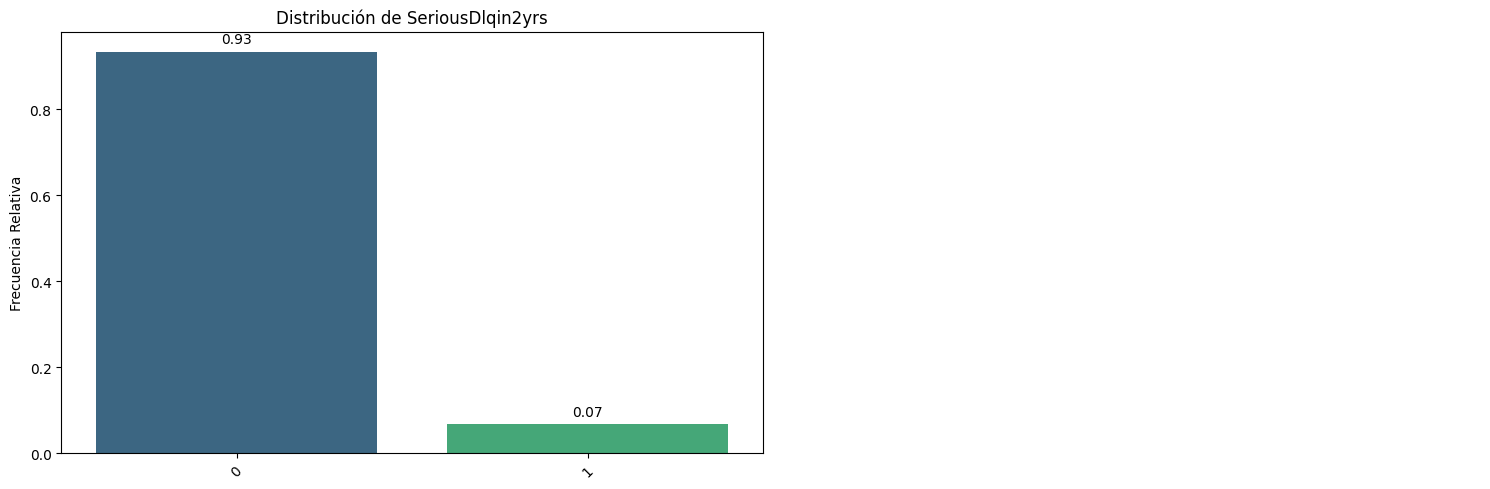

In [86]:
bt.pinta_distribucion_categoricas(train_set, [target], mostrar_valores= True, relativa= True)

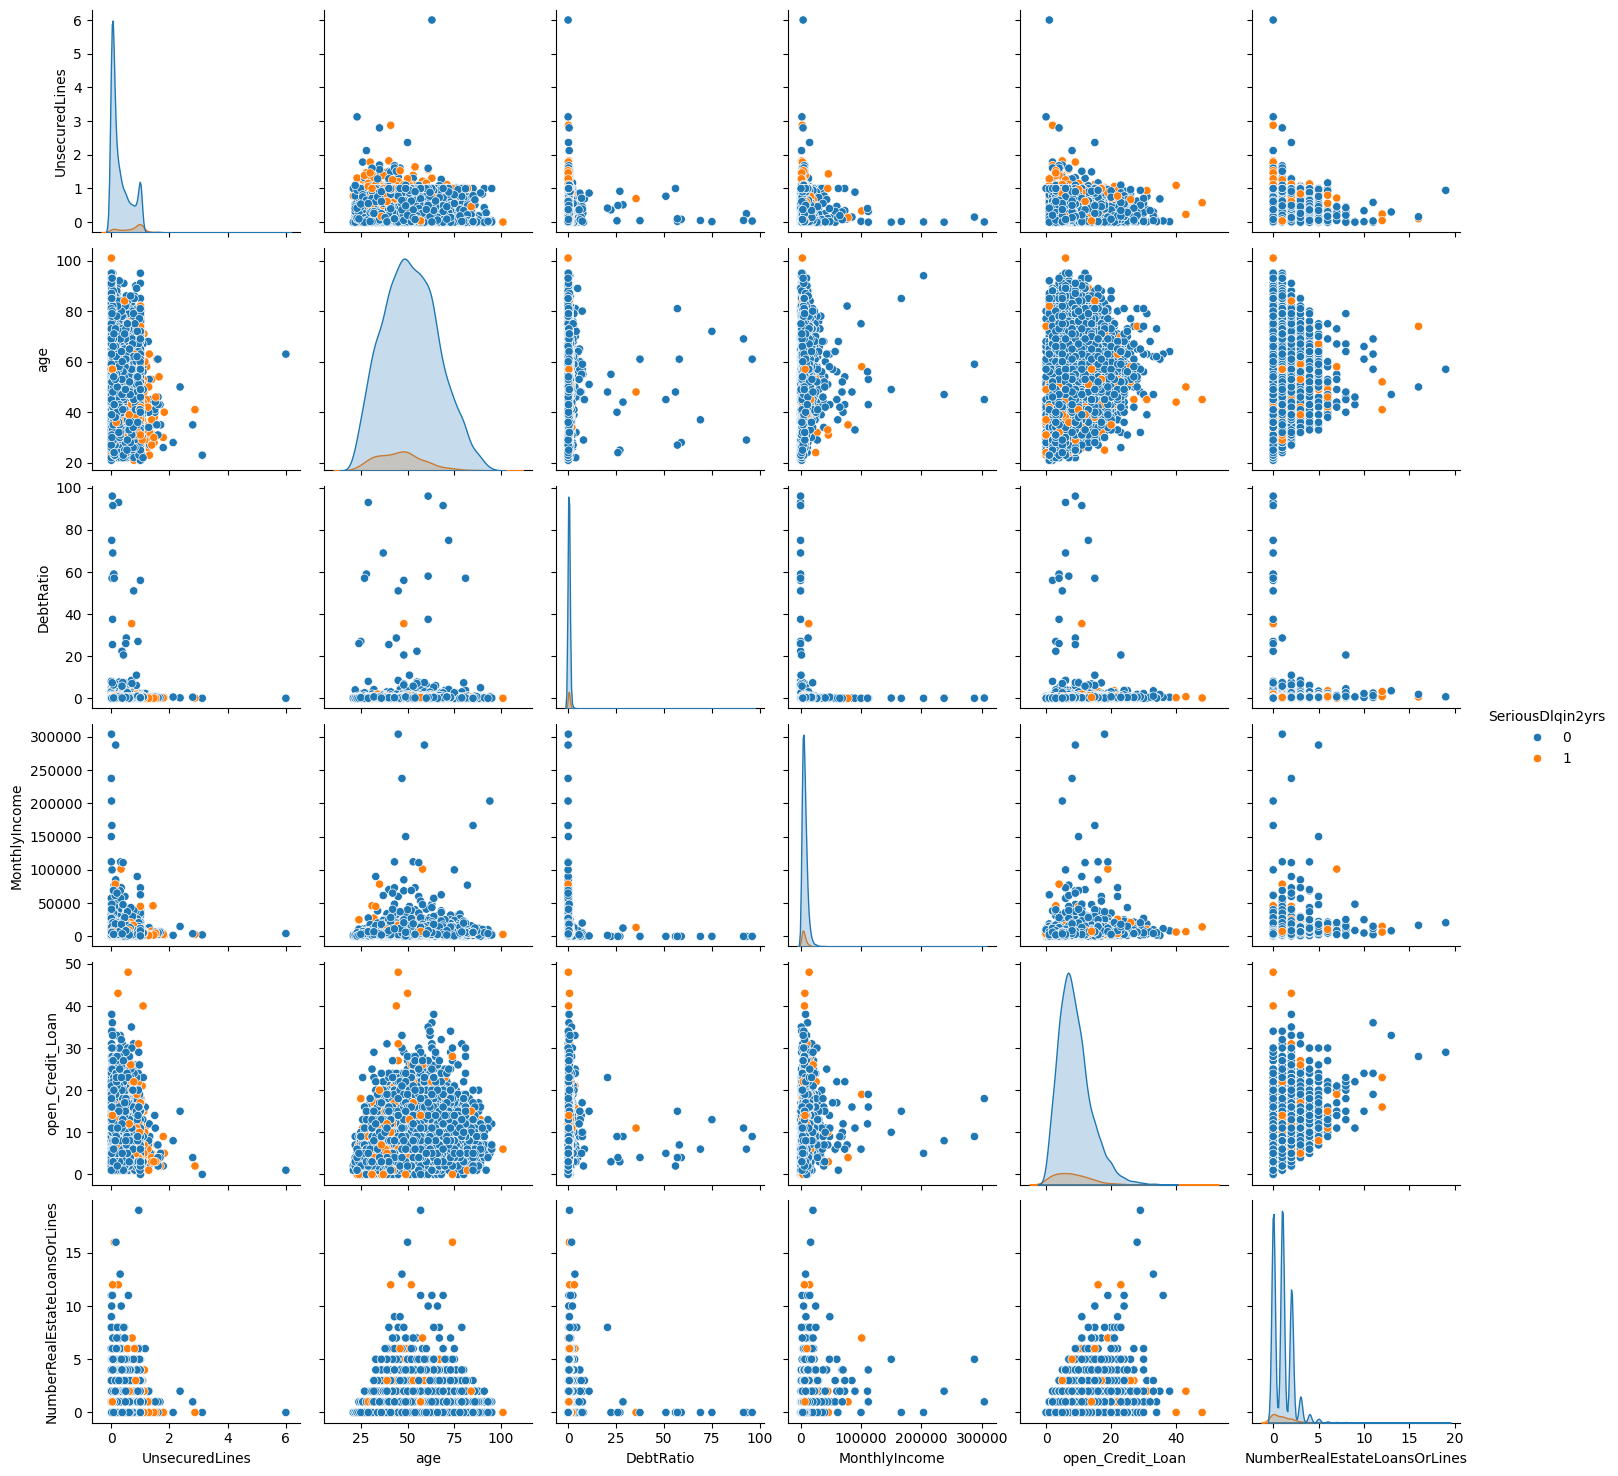

In [87]:
sns.pairplot(train_set, hue = target)

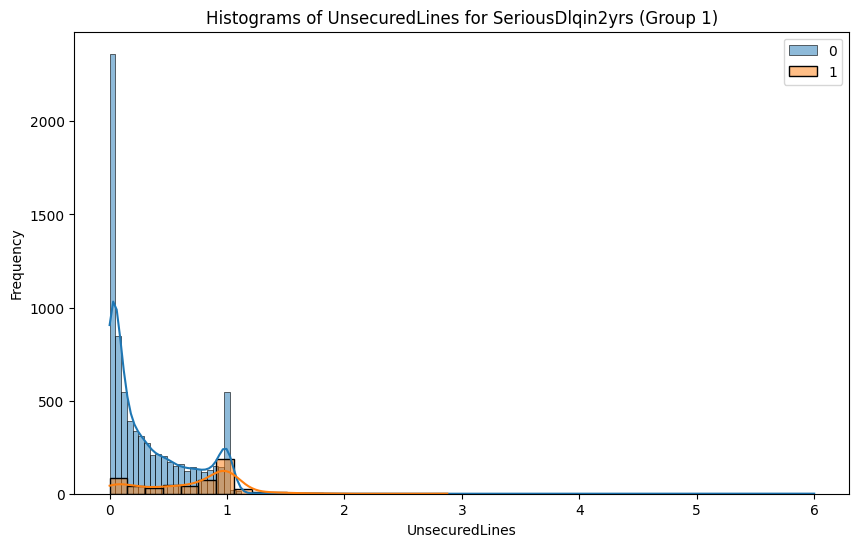

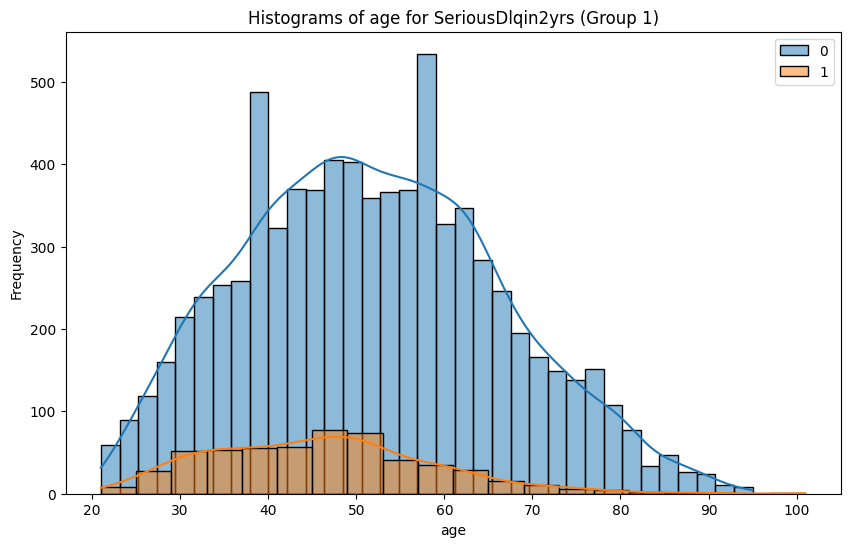

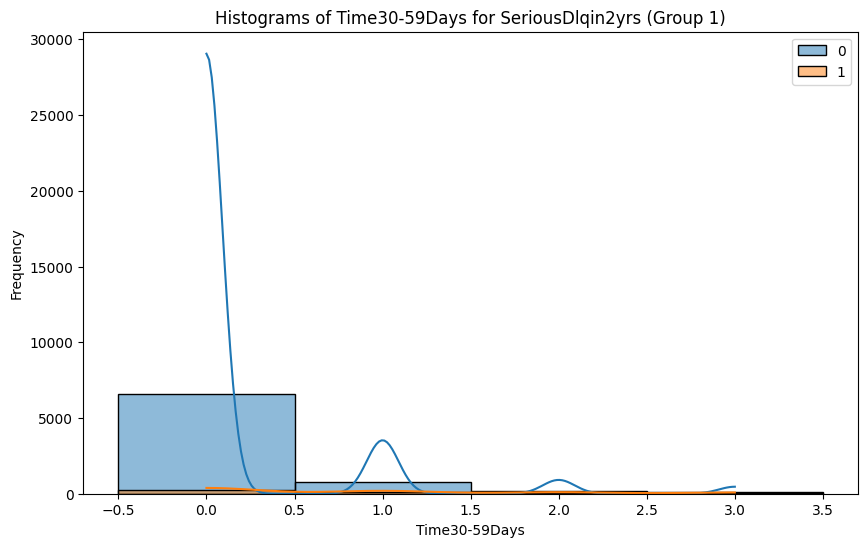

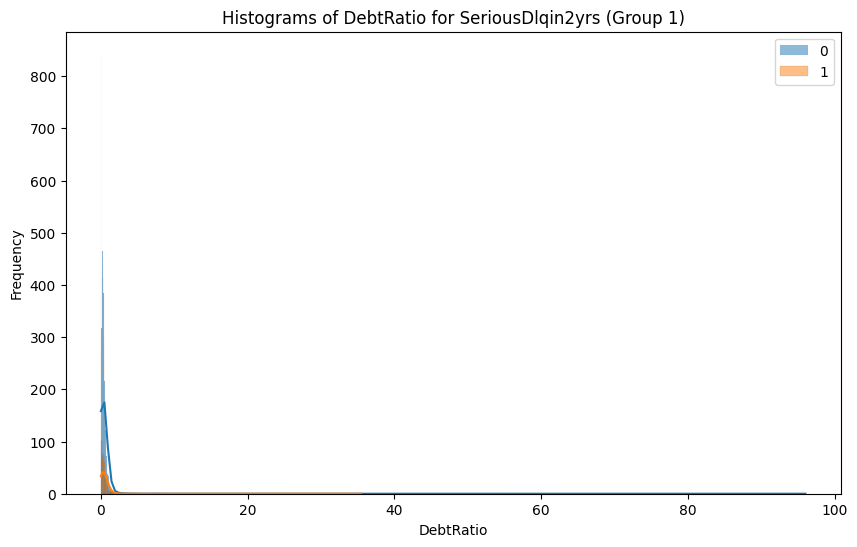

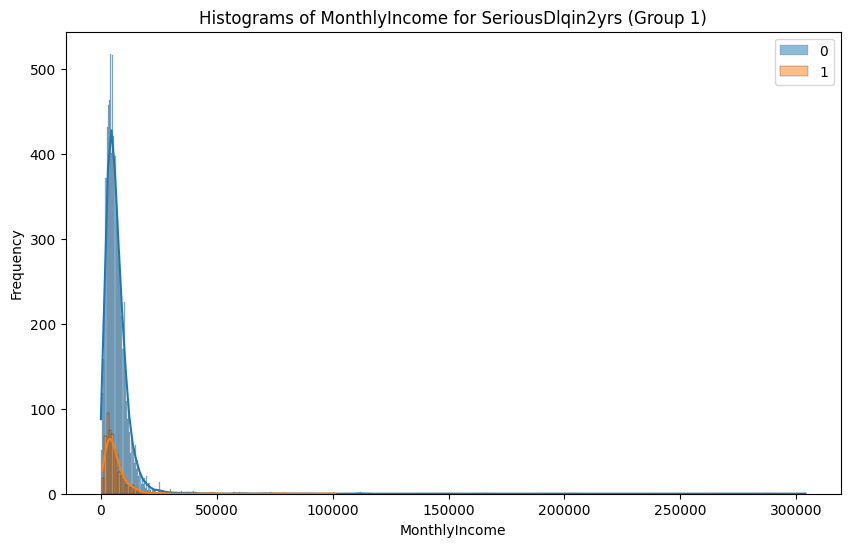

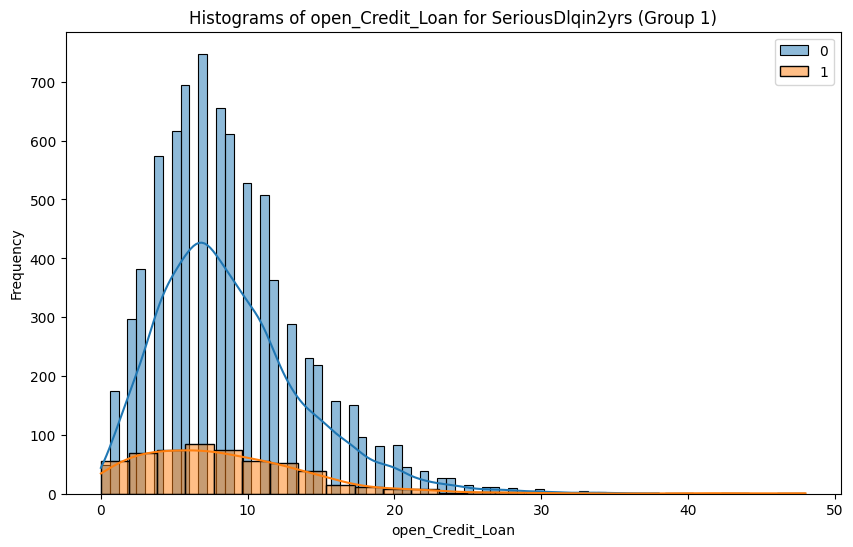

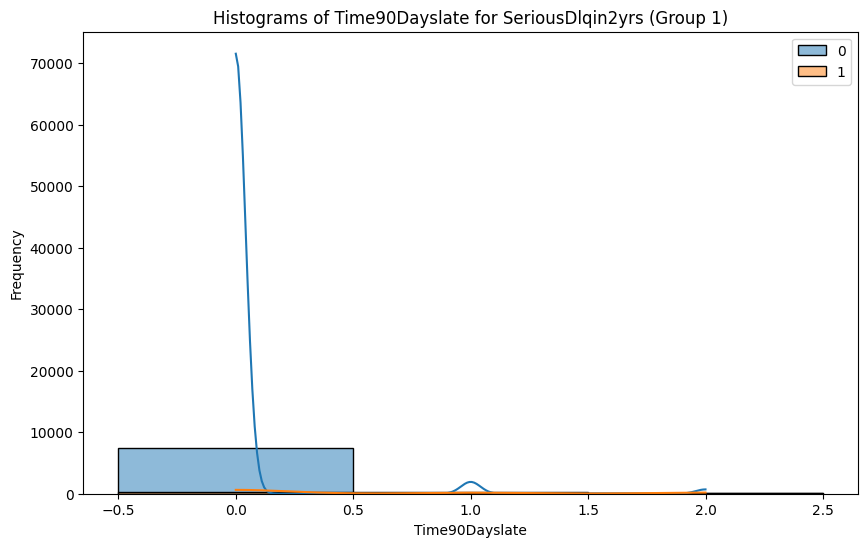

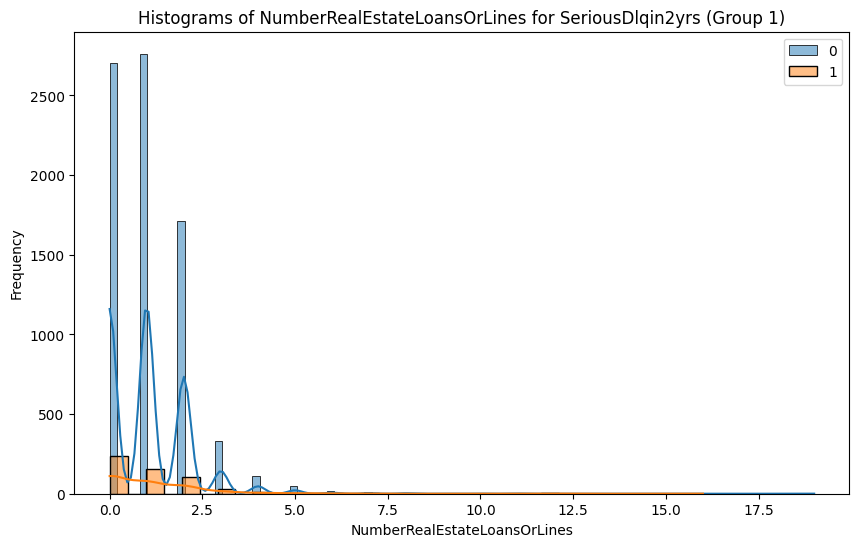

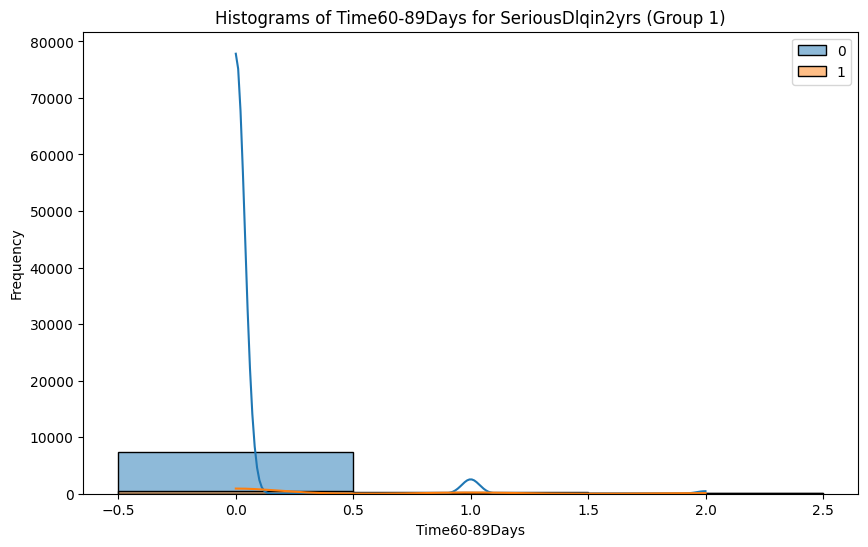

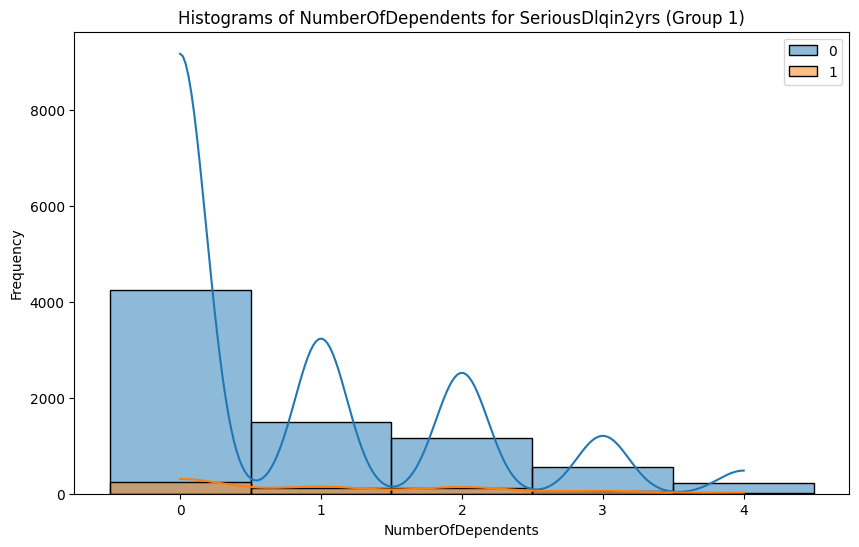

In [88]:
for col in train_set.columns:
    if col != target:
        bt.plot_grouped_histograms(train_set, target, col, group_size = 2)

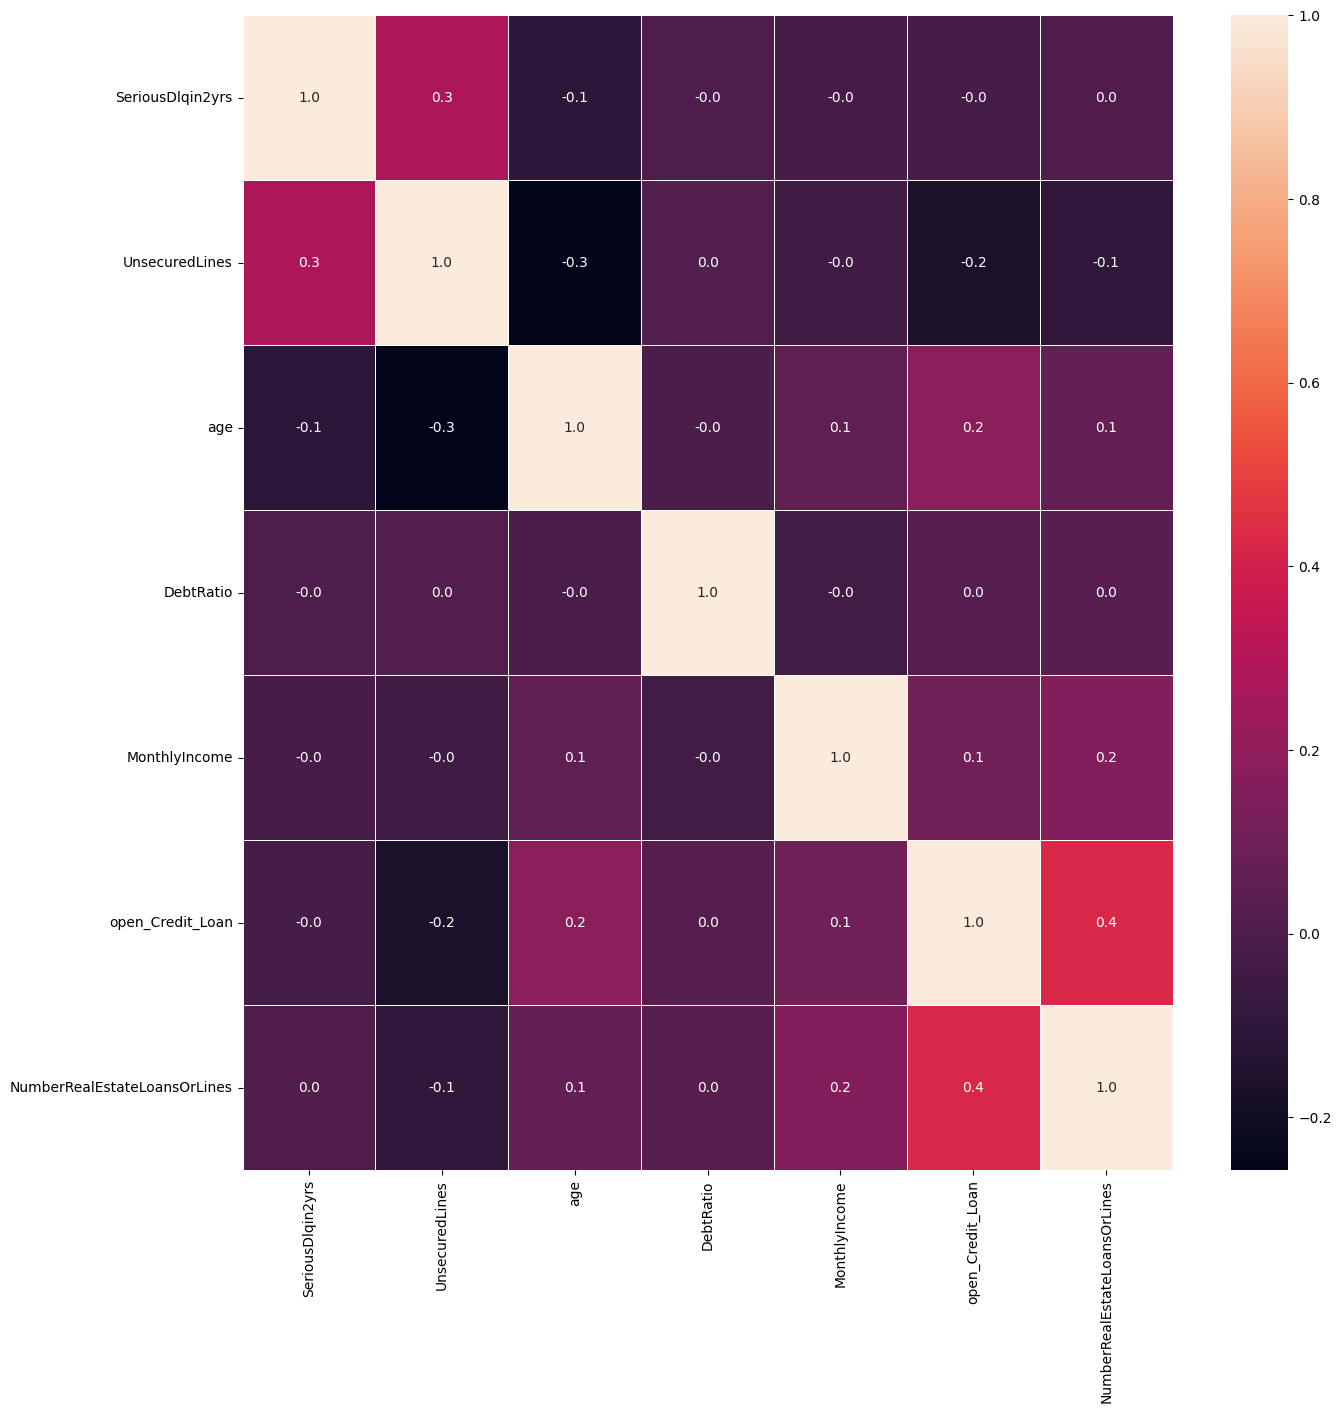

In [22]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(numeric_only=True), annot=True, linewidths=.5, fmt= '.1f');

In [30]:
import numpy as np

corr= df[features_num+["SeriousDlqin2yrs"]].corr()
serie_corr = np.abs(corr["SeriousDlqin2yrs"])
serie_corr[serie_corr>0.1].sort_values(ascending = False)

SeriousDlqin2yrs    1.000000
UnsecuredLines      0.278037
age                 0.105705
Name: SeriousDlqin2yrs, dtype: float64

In [ ]:
# target cat + categoricas
from sklearn.metrics import mutual_info_score
target = "SeriousDlqin2yrs"
df_mi = df.dropna()
for col in transformed_cat:
    print(f"MI({col}; con {target}):", mutual_info_score(df_mi[col],df_mi[target])*100)

MI(Time30-59Days; con SeriousDlqin2yrs): 2.258211750577292
MI(NumberOfDependents; con SeriousDlqin2yrs): 0.12417080285679408
MI(Time60-89Days; con SeriousDlqin2yrs): 1.8627542257257046
MI(Time90Dayslate; con SeriousDlqin2yrs): 3.385878246343841


In [54]:
manualinfoscore=  ["Time90Dayslate", "Time90Dayslate"]
manualinfoscore

['Time90Dayslate', 'Time90Dayslate']

In [118]:
from sklearn.feature_selection import SelectKBest, f_classif 

'''
f_classif realiza un test ANOVA
a técnica de análisis de varianza (ANOVA) también conocida como análisis factorial y desarrollada por Fisher en 1930,
constituye la herramienta básica para el estudio del efecto de uno o más factores (cada uno con dos o más niveles) sobre
la media de una variable continua. Es por lo tanto el test estadístico a emplear cuando se desea comparar las medias de
dos o más grupos.
'''
#features_num.remove("quality")
X_train = df[features_num]
y_train = df["SeriousDlqin2yrs"]
selector = SelectKBest(f_classif, k=4)
x_data_kbest = selector.fit_transform(X_train, y_train)
X_train_kbest = pd.DataFrame(x_data_kbest, columns = selector.get_feature_names_out())
X_train_kbest.columns.to_list


<bound method IndexOpsMixin.tolist of Index(['UnsecuredLines', 'age', 'MonthlyIncome', 'open_Credit_Loan'], dtype='object')>

In [ ]:
from sklearn.datasets import make_classification
from sklearn.feature_selection import mutual_info_classif # target cat y features cat
X, y = make_classification(
    n_samples=100, n_features=4, n_informative=2, n_clusters_per_class=1,
    shuffle=False, random_state=42
)
mutual_info_classif(X, y)

array([0.58875393, 0.10657571, 0.19641896, 0.0968634 ])

In [42]:
#3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
from sklearn.ensemble import RandomForestClassifier
rf_selector = RandomForestClassifier(random_state= 42)
rf_selector.fit(X_train,y_train)
rf_selector.feature_importances_[rf_selector.feature_importances_ > rf_selector.feature_importances_.mean()]

array([0.27365191, 0.21119747, 0.2058445 ])

In [43]:
from sklearn.feature_selection import SelectFromModel
selector_model = SelectFromModel(estimator = rf_selector, threshold= "median") # El modelo debe tener un atributo feature_importances_ o un atributo coef_
selector_model.fit(df[features_num],df["SeriousDlqin2yrs"])

SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                threshold='median')

In [46]:
select_from_model = selector_model.get_feature_names_out()
select_from_model

array(['UnsecuredLines', 'DebtRatio', 'MonthlyIncome'], dtype=object)

4. Selección de las mejores features empleando RFE.
5. Selección de las mejores features empleando SFS.

In [48]:
from sklearn.feature_selection import RFE

rf_RFE = RandomForestClassifier(random_state= 42) # Puedes usar tu modelo, o modelos a probar o un modelo "proxy" como en la selección por modelo

rfe = RFE(estimator = rf_RFE,
          n_features_to_select= 4, # Iterará hasta quedarse con 5
          step = 1) # Elimina de una en una, pero es configurable

rfe.fit(X_train, y_train)
print(rfe.ranking_)
pd.DataFrame(rfe.ranking_, columns= ["ranking"], index = features_num).sort_values("ranking")

[1 1 1 1 2 3]


,ranking
UnsecuredLines,1
age,1
DebtRatio,1
MonthlyIncome,1
open_Credit_Loan,2
NumberRealEstateLoansOrLines,3


In [55]:
RFE_list=["unsecuredLines", "age", "DebtRatio", "MonthlyIncome"]

In [49]:
from sklearn.feature_selection import SequentialFeatureSelector

rf_SFS = RandomForestClassifier(random_state = 42)

sfs_forward = SequentialFeatureSelector(rf_SFS,
                                        n_features_to_select = 4,
                                        cv = 4,
                                        scoring = "balanced_accuracy")


sfs_forward.fit(X_train, y_train)

SequentialFeatureSelector(cv=4,
                          estimator=RandomForestClassifier(random_state=42),
                          n_features_to_select=4, scoring='balanced_accuracy')

In [50]:
print("Elegidasd SFS:", sfs_forward.get_feature_names_out())

Elegidasd SFS: ['UnsecuredLines' 'age' 'DebtRatio' 'NumberRealEstateLoansOrLines']


In [89]:
SFS_list = sfs_forward.get_feature_names_out()

6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

In [114]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [120]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

feature_sets = {
    "manualinfoscore" : manualinfoscore,
    "x_data_kbest" : X_train_kbest.columns.to_list(),
    "select_from_model" : select_from_model,
    "RFE_list" : RFE_list,
    "SFS_list" : SFS_list
    }

models = {
    "Regresión Logística": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]),
    
    "k-NN con SMOTE": Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ]),
    
    "Árbol de Decisión": DecisionTreeClassifier(class_weight='balanced')
}

for nombre, lista in feature_sets.items():
    print(f"Feature Set: {nombre} ")

    for name, model in models.items():
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        print(f"\n Modelo: {name}")
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("Reporte de Clasificación:\n", classification_report(y_test, y_pred))
        print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))

Feature Set: manualinfoscore 

 Modelo: Regresión Logística
Accuracy: 1.0
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Matriz de Confusión:
 [[15  0]
 [ 0 15]]

 Modelo: k-NN con SMOTE
Accuracy: 1.0
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Matriz de Confusión:
 [[15  0]
 [ 0 15]]

 Modelo: Árbol de Decisión
Accuracy: 1.0
Reporte de Clasificación:
               precision    r

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.